##PARTIE 1:Introduction & Business Context


Présentation du projet "Drone Hubs Ghana", rappel du partenariat avec Zipline et de l'objectif : atteindre 100% de couverture sanitaire.

##PARTIE 2 : Initialisation et Chargement


In [1]:
#On prépare l'environnement et on importe les données brutes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, Fullscreen
from geopy.distance import geodesic
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Chargement des Datasets
df_health = pd.read_csv('ghana_health_facilities.csv')
df_villages = pd.read_csv('ghana_villages_clean.csv')

In [3]:
#Inspection rapide (santé)
print(df_health.info())
display(df_health.describe())
display(df_health.head())

<class 'pandas.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Facility_Name     2463 non-null   str    
 1   Facility_Type     2463 non-null   str    
 2   Latitude          2463 non-null   float64
 3   Longitude         2463 non-null   float64
 4   Data_Sources      2463 non-null   str    
 5   Confidence_Score  2463 non-null   float64
 6   OSM_ID            2463 non-null   int64  
 7   Operator          192 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 154.1 KB
None


,Latitude,Longitude,Confidence_Score,OSM_ID
count,2463.000000,2463.000000,2463.000000,2.463000e+03
mean,6.499642,-0.674366,0.709233,6.208373e+09
std,1.453120,0.917755,0.139707,3.678602e+09
min,4.866764,-3.182800,0.130000,1.541730e+08
25%,5.596990,-1.507801,0.610000,2.153199e+09
50%,5.732802,-0.243086,0.810000,6.673370e+09
75%,6.812662,-0.112437,0.810000,8.900384e+09
max,11.115618,1.194860,0.950000,1.364680e+10


,Facility_Name,Facility_Type,Latitude,Longitude,Data_Sources,Confidence_Score,OSM_ID,Operator
0,Abotanse CHPs Compound,CHPS,7.079881,-0.095769,"OSM,HDX",0.67,8507017600,NaN
1,Adaklu Ablornu CHPs Compound,CHPS,6.348821,0.636714,"OSM,HDX",0.67,8564385285,NaN
2,Adukrom CHPs Compound,CHPS,7.014006,-0.095263,"OSM,HDX",0.67,8507559106,NaN
3,Agordeke CHPs Compound,CHPS,7.055806,0.120353,"OSM,HDX",0.67,8510344969,NaN
4,Akome CHPs Compound,CHPS,6.820077,0.467840,"OSM,HDX",0.67,8583291384,NaN


In [4]:
#Inspection Rapide (Villages)
print(df_villages.info())
display(df_villages.describe())

<class 'pandas.DataFrame'>
RangeIndex: 8905 entries, 0 to 8904
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Village                       8905 non-null   str    
 1   Latitude                      8905 non-null   float64
 2   Longitude                     8905 non-null   float64
 3   Elevation_m                   8905 non-null   float64
 4   Population                    8905 non-null   float64
 5   Population_Source             8905 non-null   str    
 6   Place_Type                    8905 non-null   str    
 7   Nearest_Facility_Name         8905 non-null   str    
 8   Nearest_Facility_Type         8905 non-null   str    
 9   Nearest_Facility_Latitude     8905 non-null   float64
 10  Nearest_Facility_Longitude    8905 non-null   float64
 11  Distance_Nearest_Facility_km  8905 non-null   float64
 12  Nearest_Facility_Confidence   8905 non-null   float64
dtypes: float64(8),

,Latitude,Longitude,Elevation_m,Population,Nearest_Facility_Latitude,Nearest_Facility_Longitude,Distance_Nearest_Facility_km,Nearest_Facility_Confidence
count,8905.000000,8905.000000,8905.000000,8.905000e+03,8905.000000,8905.000000,8905.000000,8905.000000
mean,7.058856,-1.113893,177.841437,6.210639e+03,7.054646,-1.113331,9.261330,0.667898
std,1.527181,0.952292,97.618012,4.634090e+04,1.530712,0.957432,8.853003,0.149349
min,4.739811,-3.246019,-2.000000,5.000000e+00,4.866764,-3.182800,0.010000,0.130000
25%,5.923368,-1.832259,110.000000,4.390000e+02,5.868827,-1.842307,2.920000,0.530000
50%,6.607157,-1.032793,171.000000,9.070000e+02,6.613570,-0.993307,7.070000,0.630000
75%,7.671473,-0.336698,241.000000,2.627000e+03,7.738077,-0.343671,12.580000,0.810000
max,11.148113,1.196421,719.000000,2.388000e+06,11.115618,1.188693,64.710000,0.950000


##PARTIE 2 : Nettoyage et Préparation (Feature Engineering)

In [5]:
#Correction des Coordonnées (Santé)
# Correction du décalage des colonnes si Latitude contient du texte
mask = df_health['Latitude'].astype(str).str.contains('[a-zA-Z]', na=False)
if mask.any():
    cols = df_health.columns.tolist()
    idx_type, idx_lat = cols.index('Facility_Type'), cols.index('Latitude')
    df_health.loc[mask, cols[idx_type:-1]] = df_health.loc[mask, cols[idx_lat:]].values

df_health['Latitude'] = pd.to_numeric(df_health['Latitude'], errors='coerce')
df_health['Longitude'] = pd.to_numeric(df_health['Longitude'], errors='coerce')
df_health = df_health.dropna(subset=['Latitude', 'Longitude'])

In [6]:
#Catégorisation simplifiée (EDA)
def categorize(t):
    t = str(t).lower()
    if 'hospital' in t: return 'Hospital'
    if 'clinic' in t: return 'Clinic'
    if 'chps' in t: return 'CHPS'
    return 'Other'

df_health['Category'] = df_health['Facility_Type'].apply(categorize)
# Sauvegarde du dataset propre
df_health.to_csv('health_master_clean.csv', index=False)

##PARTIE 3 : Analyse Stratégique (Croisement des Datasets)

In [7]:
#Calcul de la distance au réseau Zipline actuel
#On définit les 6 hubs existants et on mesure la distance pour chaque centre de santé
ZIPLINE_HUBS = [
    {"name": "Omenako", "loc": [6.2027, -0.4462]}, {"name": "Mpanya", "loc": [7.0545, -1.3855]},
    {"name": "Vobsi", "loc": [10.3470, -0.8035]}, {"name": "Sefwi Wiawso", "loc": [6.1820, -2.4845]},
    {"name": "Anum", "loc": [6.4885, 0.1625]}, {"name": "Kete Krachi", "loc": [7.7981, -0.0125]}
]

def get_dist_zipline(row):
    p = (row['Latitude'], row['Longitude'])
    return min([geodesic(p, h['loc']).km for h in ZIPLINE_HUBS])

df_health['Dist_Zipline_km'] = df_health.apply(get_dist_zipline, axis=1)
df_health['Is_Covered'] = (df_health['Dist_Zipline_km'] <= 80).astype(int)


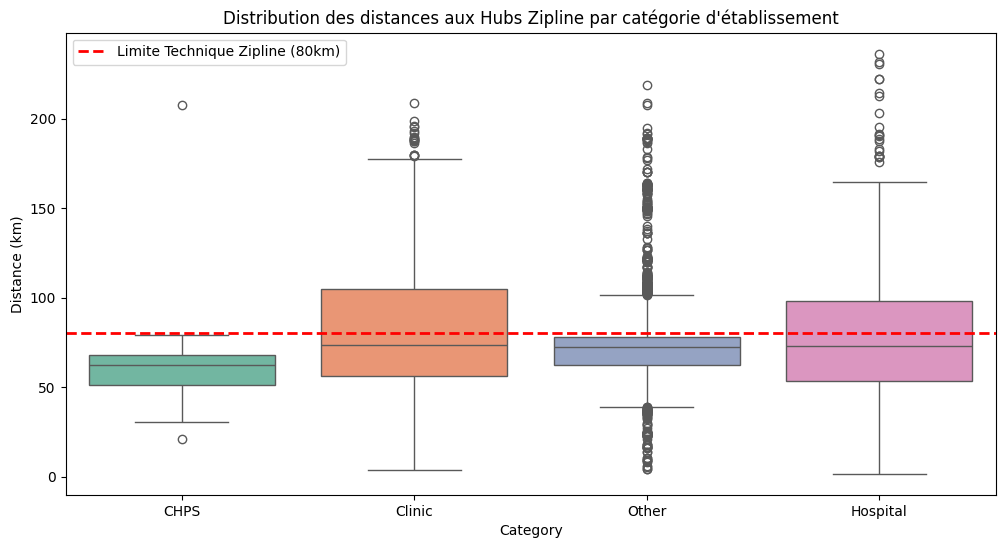

In [8]:
#La Boîte à Moustaches (Le constat d'échec de couverture)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_health, x='Category', y='Dist_Zipline_km', palette='Set2')
plt.axhline(80, color='red', linestyle='--', linewidth=2, label='Limite Technique Zipline (80km)')
plt.title("Distribution des distances aux Hubs Zipline par catégorie d'établissement")
plt.ylabel("Distance (km)")
plt.legend()
plt.show()

# Conclusion : Si la médiane (ligne centrale du box) est au-dessus de 80, 
# alors plus de 50% de cette catégorie n'est pas couverte.

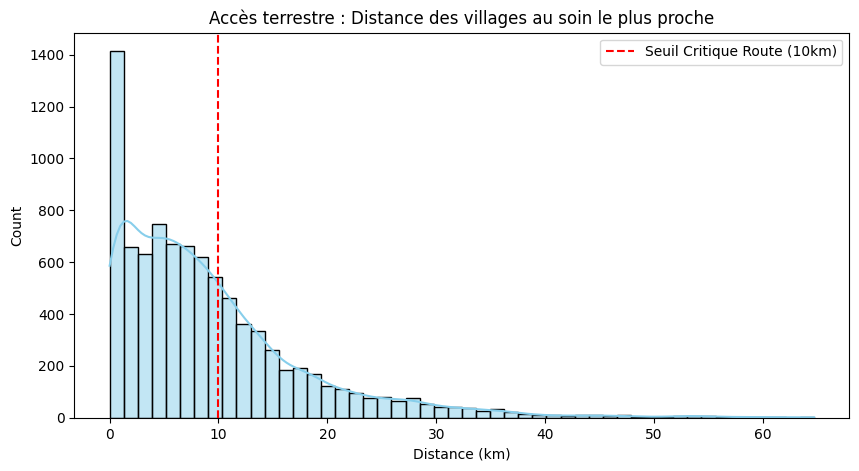

Population en zone critique terrestre : 4,661,008 habitants


In [9]:
#Analyse de l'isolement des Villages (Dataset 2)
plt.figure(figsize=(10, 5))
sns.histplot(df_villages['Distance_Nearest_Facility_km'], bins=50, color='skyblue', kde=True)
plt.axvline(10, color='red', linestyle='--', label='Seuil Critique Route (10km)')
plt.title("Accès terrestre : Distance des villages au soin le plus proche")
plt.xlabel("Distance (km)")
plt.legend()
plt.show()

pop_isolee = df_villages[df_villages['Distance_Nearest_Facility_km'] > 10]['Population'].sum()
print(f"Population en zone critique terrestre : {pop_isolee:,.0f} habitants")

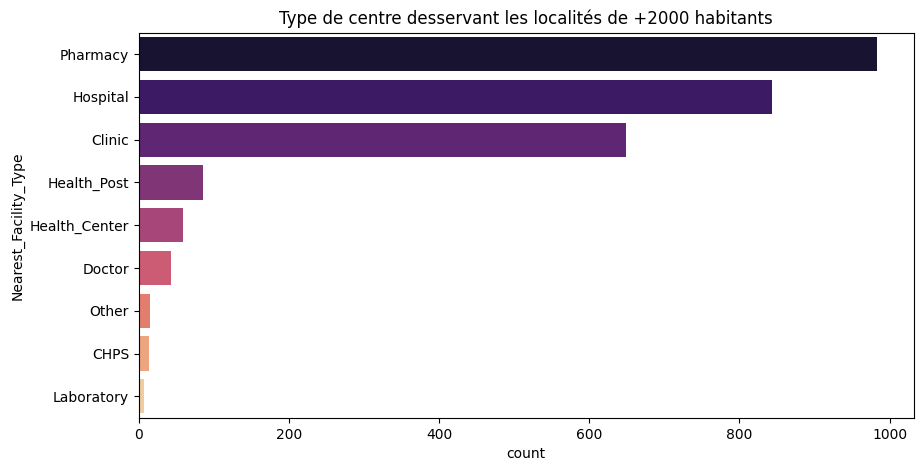

In [10]:
#Corrélation Population vs Type de Centre (Le Mismatch)
# Analyse sur les localités de +2000 habitants
gros_villages = df_villages[df_villages['Population'] >= 2000]

plt.figure(figsize=(10, 5))
sns.countplot(data=gros_villages, y='Nearest_Facility_Type', palette='magma', 
              order=gros_villages['Nearest_Facility_Type'].value_counts().index)
plt.title("Type de centre desservant les localités de +2000 habitants")
plt.show()

In [11]:
#Conclusion de l'état des lieux (La Carte du Besoin)
# Ajout de la distance Zipline aux villages aussi pour la heatmap
df_villages['Dist_Zipline_km'] = df_villages.apply(get_dist_zipline, axis=1)

df_health.to_csv('ghana_health_eda_final.csv', index=False)
df_villages.to_csv('ghana_villages_eda_final.csv', index=False)
print("Fichiers prêts pour l'étape de modélisation (K-Means)")

Fichiers prêts pour l'étape de modélisation (K-Means)


In [13]:
import folium
from folium.plugins import HeatMap, Fullscreen

# --- 1. CONFIGURATION DE LA CARTE (OPENSTREETMAP) ---
m_eda = folium.Map(location=[7.9, -1.0], zoom_start=7, tiles='OpenStreetMap')

# Couleurs Standard MASA
COLOR_MAP = {
    'Hospital': '#E74C3C',      # Rouge
    'Clinic': '#3498DB',        # Bleu
    'CHPS': '#2ECC71',          # Vert
    'Health Centre': '#F1C40F', # Jaune
    'Other': '#95A5A6'          # Gris
}

# --- 2. GESTION DES COORDONNÉES ZIPLINE (SÉCURITÉ) ---
try:
    zipline_points = [h['loc'] if isinstance(h, dict) else h for h in ZIPLINE_HUBS]
except NameError:
    zipline_points = []

# --- 3. CRÉATION DES COUCHES ---
fg_pop = folium.FeatureGroup(name="👥 Densité Population Totale (Heatmap)", show=True).add_to(m_eda)
fg_health = folium.FeatureGroup(name="🏥 Points de Santé (Catégories)", show=True).add_to(m_eda)
fg_zip = folium.FeatureGroup(name="🚀 Réseau Zipline Actuel", show=True).add_to(m_eda)

# --- 4. AJOUT DES ÉLÉMENTS ---

# A. Heatmap : Densité de population TOTALE (df_villages complet)
HeatMap(df_villages[['Latitude', 'Longitude']].values, radius=10, blur=15).add_to(fg_pop)

# B. Points de Santé
for _, row in df_health.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2, 
        color=COLOR_MAP.get(row['Category'], '#7F8C8D'),
        fill=True, fill_opacity=0.7, weight=1,
        popup=f"{row['Facility_Name']} ({row['Category']})"
    ).add_to(fg_health)

# C. Hubs Zipline existants (Noir)
for pt in zipline_points:
    folium.Marker(pt, icon=folium.Icon(color='black', icon='plane', prefix='fa')).add_to(fg_zip)
    folium.Circle(pt, radius=80000, color='black', fill=True, opacity=0.05, weight=1).add_to(fg_zip)

# --- 5. LÉGENDE STYLE DASHBOARD (AGRANDIE & LISIBLE) ---
legend_html = f'''
<div style="position: fixed; bottom: 30px; left: 30px; width: 340px; z-index:9999; 
     background-color: rgba(255, 255, 255, 0.95); padding: 20px; border: 3px solid #333; border-radius: 12px; 
     font-family: Arial, sans-serif; box-shadow: 0 0 15px rgba(0,0,0,0.2);">
     
     <h3 style="margin-top:0; color:#333; font-size:18px; border-bottom: 2px solid #ddd; padding-bottom:10px; margin-bottom:12px; font-weight:bold;">📊 DIAGNOSTIC : COUVERTURE</h3>
     
     <div style="font-size:15px; line-height:1.6; color:#333; font-family: Arial, sans-serif;">
        <b style="display:block; margin-bottom:8px;">Types d'établissements :</b>
        <table style="width:100%;">
            <tr><td><i style="background:{COLOR_MAP['Hospital']};width:12px;height:12px;display:inline-block;border-radius:2px;"></i> Hospital</td>
                <td><i style="background:{COLOR_MAP['Clinic']};width:12px;height:12px;display:inline-block;border-radius:2px;margin-left:10px;"></i> Clinic</td></tr>
            <tr><td><i style="background:{COLOR_MAP['CHPS']};width:12px;height:12px;display:inline-block;border-radius:2px;"></i> CHPS</td>
                <td><i style="background:{COLOR_MAP['Health Centre']};width:12px;height:12px;display:inline-block;border-radius:2px;margin-left:10px;"></i> Health Centre</td></tr>
            <tr><td><i style="background:{COLOR_MAP['Other']};width:12px;height:12px;display:inline-block;border-radius:2px;"></i> Autre</td><td></td></tr>
        </table>
        
        <hr style="margin:12px 0; border: 0.5px solid #eee;">
        
        <b style="display:block; margin-bottom:8px;">Infrastructure existante :</b>
        <i style="background:black;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Hub Zipline (Rayon 80km)<br>
        <i style="background:orange;width:12px;height:12px;display:inline-block;border-radius:2px;margin-top:5px; opacity:0.6;"></i> Zone de forte densité (Heatmap)
     </div>
     
     <div style="margin-top:15px; font-size:13px; color:#555; font-style: italic; border-top:1px solid #eee; padding-top:10px;">
        Objectif : Visualiser les zones de population non couvertes par le réseau actuel.
     </div>
</div>
'''
m_eda.get_root().html.add_child(folium.Element(legend_html))

# --- 6. STYLE DU FILTRE ET FINITIONS ---
filter_style = """
<style>
    .leaflet-control-layers-overlays {
        font-size: 16px !important;
        font-family: Arial, sans-serif !important;
        font-weight: bold !important;
        padding: 10px;
    }
</style>
"""
m_eda.get_root().header.add_child(folium.Element(filter_style))

folium.LayerControl(position='topright', collapsed=False).add_to(m_eda)
Fullscreen(position='topright').add_to(m_eda)

# Affichage
m_eda